# Slug Clustering by Country Coverage

Groups slugs by their country coverage patterns using Jaccard similarity on binary presence matrices.
Missingness is signal — the absence of an indicator for a country is valuable information.

**Phase 1: Model Definition**

In [1]:
using Revise
using InteractiveUtils

includet("phase1/functions/load_phase1.jl")

╔══════════════════════════════════════════════════════════════════════════╗
║ QoG METADATA JOINING - PHASE 0 LOADED                                ║
╚══════════════════════════════════════════════════════════════════════════╝

Quick Start:
    metadata = join_metadata()              # Run full pipeline (single isomorphism check)
    metadata = join_metadata_with_cascade()  # Run cascade (strictest → loosest), then union on slug
    quick_check()                             # Diagnostic check
    inspect_exceptions()                      # Review configuration
    show_usage()                              # Detailed documentation

Pipeline Steps:
    1. ingest_and_normalize()            # Load & normalize sources (PDF = qog_slugs_temporal.csv; min_year/max_year ingested)
    2. align_id_variables!(...)          # Harmonize ID vars
    3. run_isomorphism_cascade(...)      # Strictest → loosest until success; returns (stata_df, pdf_df, arrow_df) for union on slug
    4. unify_and_join(..

In [2]:
using CSV, DataFrames

df = load_augmented_or_build()
meta_df = CSV.read("data/qog_metadata_plus2.csv", DataFrame)
geo_df = CSV.read("data/ggis_geographic_lookup.csv", DataFrame)
pool = CSV.read("data/clustering_pool.csv", DataFrame).slug

println("Loaded: $(nrow(df)) rows, $(length(pool)) slugs in clustering pool")

✓ Checksum verified: data/qog_std_ts_jan25_aug.arrow
✓ Loaded: 12391 rows × 2014 cols from data/qog_std_ts_jan25_aug.arrow
  ggis_rowid unique: ✓ | Required columns: ✓ | Missing regions: 0 ✓
Loaded: 12391 rows, 643 slugs in clustering pool


## Run Clustering Pipeline

Default thresholds — adjust as needed.

In [3]:
# Load pre-filtered pool from reclassification
pool = CSV.read("data/clustering_pool.csv", DataFrame).slug
println("Clustering pool: $(length(pool)) slugs")

# All countries in matrix — no clean_ccodes filtering
result = run_slug_clustering(df, meta_df, geo_df; slugs=pool)

Clustering pool: 643 slugs
Slug Clustering — Pre-filtered Pool
    Input slugs: 643

Step 1 — Building slug × country presence matrix
    Countries: 200
    Candidate slugs: 643
    Valid in DataFrame: 643
    presence_min_pct: 0.1
    presence_max_pct: 0.95
    min_country_coverage: 0.05
    Passing slugs: 628 (filtered 15 below coverage threshold)
    ⚠️  Near-global slugs flagged: 10
    Matrix: 628 slugs × 200 countries
    Non-zeros: 64370 (51.25% density)

Step 2 — Jaccard top-k edges
    Slugs: 628
    Countries: 200
    k: 20, min_sim: 0.1
    Directed edges: 12560
    Similarity range: 0.139 — 1.0
    Median similarity: 0.938

Step 3a — Symmetrize edges
    Directed edges in:   12560
    Undirected edges out: 9250
    Weight range: 0.139 — 1.0
    Bidirectional: 3310 / 9250 (35.8%)

Step 3b — Build weighted graph
    Vertices: 628
    Edges: 9250
    Connected components: 1

Step 3c — Label propagation clustering
    Clusters found: 16
    Cluster sizes: 151, 72, 72, 50, 41, 3

(matrix = (X = sparse([3, 4, 5, 6, 7, 8, 9, 10, 11, 12  …  606, 607, 608, 609, 610, 611, 362, 363, 364, 365], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  199, 199, 199, 199, 199, 199, 200, 200, 200, 200], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 628, 200), slug_index = ["aid_cpnc", "aid_cpsc", "aid_crnc", "aid_crnio", "aid_crsc", "aid_crsio", "ajr_settmort", "bl_asyf", "bl_asym", "bl_asymf"  …  "yri_fem40", "yri_fem4160", "yri_fem61", "yri_meanage", "yri_medianage", "yri_mp30", "yri_mp35", "yri_mp40", "yri_mp4160", "yri_mp61"], country_index = [4, 8, 12, 20, 24, 28, 31, 32, 36, 40  …  840, 854, 858, 860, 862, 882, 887, 891, 894, 9156], filtered_slugs = ["cses_pc", "cses_sd", "gtr_centaxtot1800", "mad_gdppc1000", "mad_gdppc1400", "oecd_water_t1a", "oecd_water_t1b", "wdi_birthregr", "wdi_birthregu", "wvs_auton", "wvs_conftv", "wvs_menpol", "wvs_pmi12", "wvs_satfin", "wvs_fight"], flagged_near_global = ["egov_egov", "egov_epar", "egov_

## Cluster Profiles

In [4]:
result.profiles

Row,cluster_id,n_slugs,n_prefixes,dominant_prefix,dominant_provenance,n_countries,country_coverage_pct,geographic_type,primary_region,primary_region_pct,label
,Int64,Int64,Int64,String7,String,Int64,Float64,String?,String?,Float64?,String
1,1,72,5,cpds,EVENT/FACTUAL,61,30.5,multi-regional,Europe,60.7,Mixed: cpds+ (72 slugs)
2,2,151,13,wdi,SURVEY,199,99.5,global,Africa,27.1,Global SURVEY (wdi+)
3,3,23,4,bl,SURVEY,181,90.5,global,Africa,29.8,Global SURVEY (bl+)
4,4,72,8,bti,SURVEY,173,86.5,global,Africa,31.2,Global SURVEY (bti+)
5,5,50,6,wdi,SURVEY,171,85.5,global,Asia,25.7,Global SURVEY (wdi+)
6,6,14,5,iaep,SURVEY,174,87.0,global,Africa,29.9,Global SURVEY (iaep+)
7,7,41,5,wjp,SURVEY,149,74.5,sparse,Africa,26.2,Mixed: wjp+ (41 slugs)
8,8,10,1,gfs,OFFICIAL,67,33.5,multi-regional,Europe,53.7,gfs
9,9,26,3,wdi,SURVEY,187,93.5,global,Africa,27.8,Global SURVEY (wdi+)


## ht_region Alignment

In [5]:
result.ht_validation

Row,cluster_id,best_ht_region,ht_region_jaccard,n_countries
,Int64,Int64,Float64,Int64
1,1,5,0.375,61
2,2,4,0.246,199
3,3,4,0.271,181
4,4,4,0.283,173
5,5,4,0.215,171
6,6,4,0.267,174
7,7,4,0.207,149
8,8,5,0.324,67
9,9,4,0.249,187


# Explore Cluster Strength

In [6]:
using Statistics

X = result.matrix.X
slug_index = result.matrix.slug_index
slug_to_row = Dict(s => i for (i, s) in enumerate(slug_index))
row_cards = [count(!=(0.0), X[i, :]) for i in 1:size(X, 1)]

strength_rows = []
for cid in sort(unique(result.slug_clusters.cluster_id))
    cslugs = filter(r -> r.cluster_id == cid, result.slug_clusters).slug
    idxs = [slug_to_row[s] for s in cslugs if haskey(slug_to_row, s)]
    length(idxs) < 2 && continue
    
    jaccards = Float64[]
    for i in 1:length(idxs), j in (i+1):length(idxs)
        ri, rj = idxs[i], idxs[j]
        ci, cj = row_cards[ri], row_cards[rj]
        (ci == 0 || cj == 0) && continue
        isect = count(col -> X[ri, col] > 0 && X[rj, col] > 0, 1:size(X, 2))
        jacc = isect / (ci + cj - isect)
        push!(jaccards, jacc)
    end
    
    isempty(jaccards) && continue
    push!(strength_rows, (
        cluster_id = cid,
        n_slugs = length(cslugs),
        mean_jaccard = round(mean(jaccards), digits=3),
        median_jaccard = round(median(jaccards), digits=3),
        min_jaccard = round(minimum(jaccards), digits=3),
        max_jaccard = round(maximum(jaccards), digits=3),
        pct_above_50 = round(count(>(0.5), jaccards) / length(jaccards) * 100, digits=1)
    ))
end

strength_df = DataFrame(strength_rows)
sort!(strength_df, :mean_jaccard, rev=true)


Row,cluster_id,n_slugs,mean_jaccard,median_jaccard,min_jaccard,max_jaccard,pct_above_50
,Int64,Int64,Float64,Float64,Float64,Float64,Float64
1,16,17,1.0,1.0,1.0,1.0,100.0
2,8,10,0.995,1.0,0.985,1.0,100.0
3,15,33,0.908,0.929,0.7,1.0,100.0
4,3,23,0.839,0.767,0.417,1.0,91.3
5,11,27,0.813,1.0,0.262,1.0,72.4
6,12,22,0.809,1.0,0.347,1.0,82.3
7,6,14,0.798,0.786,0.639,1.0,100.0
8,10,24,0.794,0.902,0.26,1.0,89.5
9,9,26,0.786,0.759,0.617,1.0,100.0


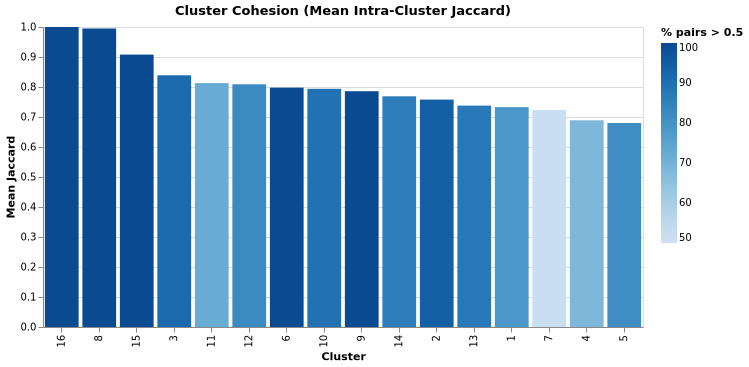

In [7]:
using VegaLite

# Overview: cluster strength bar chart
@vlplot(
    data=strength_df,
    width=600, height=300,
    title="Cluster Cohesion (Mean Intra-Cluster Jaccard)",
    mark={type=:bar},
    x={field=:cluster_id, type=:ordinal, title="Cluster", sort="-y"},
    y={field=:mean_jaccard, type=:quantitative, title="Mean Jaccard"},
    color={field=:pct_above_50, type=:quantitative, title="% pairs > 0.5",
           scale={scheme=:blues, domain=[50, 100]}}
)

In [9]:
# # Heatmap for a single cluster — change cid to explore
# cid = 2

# cslugs = filter(r -> r.cluster_id == cid, result.slug_clusters).slug
# idxs = [slug_to_row[s] for s in cslugs if haskey(slug_to_row, s)]
# n = length(idxs)

# # Build pairwise Jaccard matrix
# heat_rows = []
# for i in 1:n, j in 1:n
#     ri, rj = idxs[i], idxs[j]
#     ci, cj = row_cards[ri], row_cards[rj]
#     if i == j
#         jacc = 1.0
#     elseif ci == 0 || cj == 0
#         jacc = 0.0
#     else
#         isect = count(col -> X[ri, col] > 0 && X[rj, col] > 0, 1:size(X, 2))
#         jacc = isect / (ci + cj - isect)
#     end
#     push!(heat_rows, (slug_a=cslugs[i], slug_b=cslugs[j], jaccard=jacc))
# end
# heat_df = DataFrame(heat_rows)

# @vlplot(
#     data=heat_df,
#     width=400, height=400,
#     title="Cluster $cid — Intra-Cluster Jaccard Similarity",
#     mark=:rect,
#     x={field=:slug_a, type=:nominal, title="", axis={labelAngle=-90, labelFontSize=6}},
#     y={field=:slug_b, type=:nominal, title="", axis={labelFontSize=6}},
#     color={field=:jaccard, type=:quantitative, title="Jaccard",
#            scale={scheme=:viridis, domain=[0, 1]}}
# )


In [ ]:
# Clearly legitimate (strong internal cohesion):

# Clusters 15, 16, 9, 4 — very tight (mean J > 0.84)
# Clusters 2, 10, 12, 14, 11 — strong (mean J > 0.77)
# Solid but worth watching:

# Clusters 1, 3, 5, 6, 8, 13 — good (mean J 0.68-0.74)

## Explore Clusters for Labeling

Review each cluster's slugs AND countries to determine a country-profile label.
Labels should describe the **type of country** measured, not the data source.
Examples: `poor_reporters`, `high_gdp`, `oecd_governance`, `conflict_states`

Change `cid` to inspect different clusters.

In [22]:
cid = 10

cslugs = filter(r -> r.cluster_id == cid, result.slug_clusters)
detail = leftjoin(cslugs, meta_df[:, [:slug, :prefix, :label, :provenance, :ggis_temporal_profile]], on=:slug)
sort!(detail, [:prefix, :slug])

println("Cluster $cid: $(nrow(detail)) slugs\n")
println("--- Slugs (with peak year country count) ---")
for r in eachrow(detail)
    # Find year with most countries reporting this slug
    col = Symbol(r.slug)
    if col in propertynames(df)
        by_year = combine(
            groupby(filter(row -> !ismissing(row.ident_ccode) && !ismissing(row[col]), df), :ident_year),
            nrow => :n_countries
        )
        if nrow(by_year) > 0
            best = by_year[argmax(by_year.n_countries), :]
            peak_str = "$(best.n_countries) countries in $(best.ident_year)"
        else
            peak_str = "no data"
        end
    else
        peak_str = "not in df"
    end
    println("  $(rpad(r.slug, 28)) $(rpad(r.prefix, 8)) $(rpad(peak_str, 25)) $(r.label)")
end

# Country coverage
X = result.matrix.X
slug_idx = result.matrix.slug_index
country_idx = result.matrix.country_index
slug_to_row = Dict(s => i for (i, s) in enumerate(slug_idx))

covered = Set{Int}()
for s in cslugs.slug
    haskey(slug_to_row, s) || continue
    ri = slug_to_row[s]
    for ci in 1:length(country_idx)
        X[ri, ci] > 0 && push!(covered, country_idx[ci])
    end
end

geo_df = CSV.read("data/ggis_geographic_lookup.csv", DataFrame)
covered_df = filter(r -> r.ident_ccode in covered, geo_df)
covered_df = select(covered_df, [:ident_ccodealp, :ident_cname, :un_subregion_name, :continent])
sort!(covered_df, [:continent, :un_subregion_name, :ident_cname])

println("\n--- Countries ($(nrow(covered_df))) ---")
current_region = ""
for r in eachrow(covered_df)
    region = "$(r.continent) / $(r.un_subregion_name)"
    if region != current_region
        println("\n  $region:")
        current_region = region
    end
    println("    $(r.ident_ccodealp) $(r.ident_cname)")
end


Cluster 10: 24 slugs

--- Slugs (with peak year country count) ---
  gol_adm                      gol      141 countries in 2009     Average District Magnitude
  gol_dist                     gol      141 countries in 2009     Districts
  gol_enep                     gol      134 countries in 2017     Effective Number of Electoral Parties
  gol_enep1                    gol      133 countries in 2016     Effective Number of Electoral Parties 1
  gol_enepo                    gol      134 countries in 2017     Effective Number of Electoral Parties (Others)
  gol_enpp                     gol      142 countries in 2019     Effective Number of Parliamentary or Legislative Parties
  gol_enpp1                    gol      140 countries in 2019     Effective Number of Parliamentary or Legislative Parties, other corrected
  gol_enppo                    gol      141 countries in 2019     Effective Number of Parliamentary or Legislative Parties (Others)
  gol_enpres                   gol      80 cou

In [23]:
# Countries NOT in cluster cid
c9_slugs = filter(r -> r.cluster_id == cid, result.slug_clusters)
X = result.matrix.X
slug_idx = result.matrix.slug_index
country_idx = result.matrix.country_index
slug_to_row = Dict(s => i for (i, s) in enumerate(slug_idx))

covered = Set{Int}()
for s in c9_slugs.slug
    haskey(slug_to_row, s) || continue
    ri = slug_to_row[s]
    for ci in 1:length(country_idx)
        X[ri, ci] > 0 && push!(covered, country_idx[ci])
    end
end

all_in_matrix = Set(country_idx)
missing_ccodes = setdiff(all_in_matrix, covered)

geo_df = CSV.read("data/ggis_geographic_lookup.csv", DataFrame)
for c in sort(collect(missing_ccodes))
    row = filter(r -> r.ident_ccode == c, geo_df)
    if nrow(row) > 0
        println("  $(row.ident_ccodealp[1]) $(row.ident_cname[1])")
    else
        println("  ccode $c (not in geo lookup)")
    end
end
println("\nMissing: $(length(missing_ccodes)) countries")


  AZE Azerbaijan
  BHR Bahrain
  BRN Brunei Darussalam
  CHN China
  ERI Eritrea
  DJI Djibouti
  DDR German Democratic Republic
  IRN Iran (Islamic Republic of)
  IRQ Iraq
  CIV CÃ´te d'Ivoire
  PRK Korea (the Democratic People's Republic of)
  KWT Kuwait
  LBY Libya
  MAR Morocco
  OMN Oman
  QAT Qatar
  RWA Rwanda
  SAU Saudi Arabia
  VNM Viet Nam
  YMD Yemen Democratic
  SSD South Sudan
  SWZ Eswatini
  TJK Tajikistan
  TON Tonga
  ARE United Arab Emirates (the)
  TKM Turkmenistan
  SUN USSR
  EGY Egypt
  TZA Tanzania, the United Republic of
  BFA Burkina Faso
  UZB Uzbekistan
  YEM Yemen
  ccode 891 (not in geo lookup)
  ccode 9156 (not in geo lookup)

Missing: 34 countries


## Experiment with Thresholds

Adjust clustering dials if clusters need splitting or merging.

In [ ]:
# Tighter clusters: higher min_sim, lower k
# result_tight = run_slug_clustering(df, meta_df, geo_df;
#     presence_min_pct=0.15, min_sim=0.20, k=10)

# Looser clusters: lower min_sim, higher k
# result_loose = run_slug_clustering(df, meta_df, geo_df;
#     presence_min_pct=0.05, min_sim=0.05, k=30)

## Save Labeled Clusters

After interactive labeling, save the final assignments.

In [ ]:
# CSV.write("data/slug_clusters.csv", result.slug_clusters)
# println("✅ Saved slug_clusters.csv")

In [25]:
# cluster_labels = Dict(
#     3  => "near_global_excl_microstates",
#     6  => "near_global_excl_microstates",
#     7  => "assessable_governance_institutions",
#     8  => "capable_willing_reporters",
#     9  => "near_global",
#     10 => "codifiable_electoral_machinery",
#     12 => "moderate_institutional_visibility",
#     15 => "mature_labor_statistics",
#     16 => "established_democracies_open_parliament",
# )

# # Apply labels
# labeled = copy(result.slug_clusters)
# labeled.label = [get(cluster_labels, cid, "untagged") for cid in labeled.cluster_id]

# # Summary
# tagged = filter(r -> r.label != "untagged", labeled)
# untagged = filter(r -> r.label == "untagged", labeled)
# println("Tagged:   $(nrow(tagged)) slugs across $(length(unique(tagged.label))) labels")
# println("Untagged: $(nrow(untagged)) slugs across $(length(unique(untagged.cluster_id))) clusters")
# println()
# for lbl in sort(unique(tagged.label))
#     n = count(==(lbl), tagged.label)
#     println("  $(rpad(lbl, 45)) $n slugs")
# end

# # Save
# CSV.write("data/slug_clusters_tagged.csv", labeled)
# println("\n✅ Saved slug_clusters_tagged.csv")
